# Logistic Regression Handson


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as skl

In [26]:
# LOAD & OVERVIEW 
# csv files are normally , separated, but here it is ; separated, so we need sep=";" 
dataset = pd.read_csv('bank_logistic_regression.csv', sep=";")
df = dataset.copy()

print('shape __________________________')
print(df.shape) 

print('data type ______________________')
print(df.dtypes)

print('head ___________________________')
print(df.head())

print('null ___________________________')
print(df.isnull().sum())

print('dup ____________________________')
print(df.duplicated().sum())

print('info ___________________________')
df.info()

shape __________________________
(41199, 21)
data type ______________________
age               float64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration          float64
campaign          float64
pdays             float64
previous          float64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object
head ___________________________
    age        job  marital    education  default housing loan    contact  \
0  56.0  housemaid  married     basic.4y       no      no   no  telephone   
1  57.0   services  married  high.school  unknown      no   no  telephone   
2  37.0   services  married  high.school       no     yes   no  telephone   
3  40.0     admin.  m

In [27]:
df.sample(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
29881,43.0,technician,divorced,professional.course,unknown,yes,no,telephone,apr,mon,...,5.0,999.0,1.0,failure,-1.8,93.075,-47.1,1.405,5099.1,no
14208,36.0,admin.,married,university.degree,no,no,no,cellular,jul,mon,...,11.0,999.0,0.0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
10478,37.0,admin.,married,high.school,no,no,no,telephone,jun,tue,...,16.0,999.0,0.0,nonexistent,1.4,94.465,-41.8,4.961,5228.1,no
28756,47.0,blue-collar,married,basic.9y,no,yes,no,cellular,apr,thu,...,1.0,999.0,0.0,nonexistent,-1.8,93.075,-47.1,1.410,5099.1,no
11401,36.0,technician,married,professional.course,no,no,no,telephone,jun,fri,...,2.0,999.0,0.0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
2488,45.0,management,married,unknown,unknown,yes,no,telephone,may,tue,...,5.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.856,5191.0,no
24828,56.0,self-employed,divorced,high.school,no,no,no,cellular,nov,tue,...,1.0,999.0,0.0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,no
41118,34.0,technician,married,unknown,no,yes,no,cellular,nov,tue,...,2.0,999.0,2.0,failure,-1.1,94.767,-50.8,1.046,4963.6,no
29330,40.0,blue-collar,married,basic.4y,no,yes,no,cellular,apr,fri,...,2.0,999.0,0.0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,no
12098,28.0,technician,single,university.degree,no,no,no,telephone,jun,mon,...,2.0,999.0,0.0,nonexistent,1.4,94.465,-41.8,4.947,5228.1,no


In [28]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41194,74.0,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41195,74.0,NaN,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41196,74.0,retired,married,NaN,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---

## Target Column -> y -> the person had taken the fixed deposit / term deposit or not?
### Yes / No
### Classification Problem -> Binary Classification
### Logistic Regression

## EDA and PreProcessing ->
### EDA (Exploratory Data Analysis) -> Understand the data / Finding some patterns
### Data Preprocessing -> Whatever steps you took to modify the data to make the data clean and suitable for building a ML model

- Null Values
- Duplicates
- Outliers
- Encoding

In [29]:
print(df.isnull().sum())

age               4
job               5
marital           5
education         5
default           4
housing           3
loan              4
contact           4
month             3
day_of_week       3
duration          3
campaign          3
pdays             3
previous          3
poutcome          5
emp.var.rate      3
cons.price.idx    4
cons.conf.idx     3
euribor3m         3
nr.employed       3
y                 3
dtype: int64


In [32]:
df.dropna(how="all", inplace=True)

In [33]:
df.isnull().sum().sum()

np.int64(13)

In [34]:
df.shape

(41196, 21)

In [35]:
df.dropna(inplace=True)

In [36]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [37]:
df.duplicated().sum()

np.int64(13)

In [38]:
df.drop_duplicates(inplace=True)

In [39]:
print(df.duplicated().sum())

0


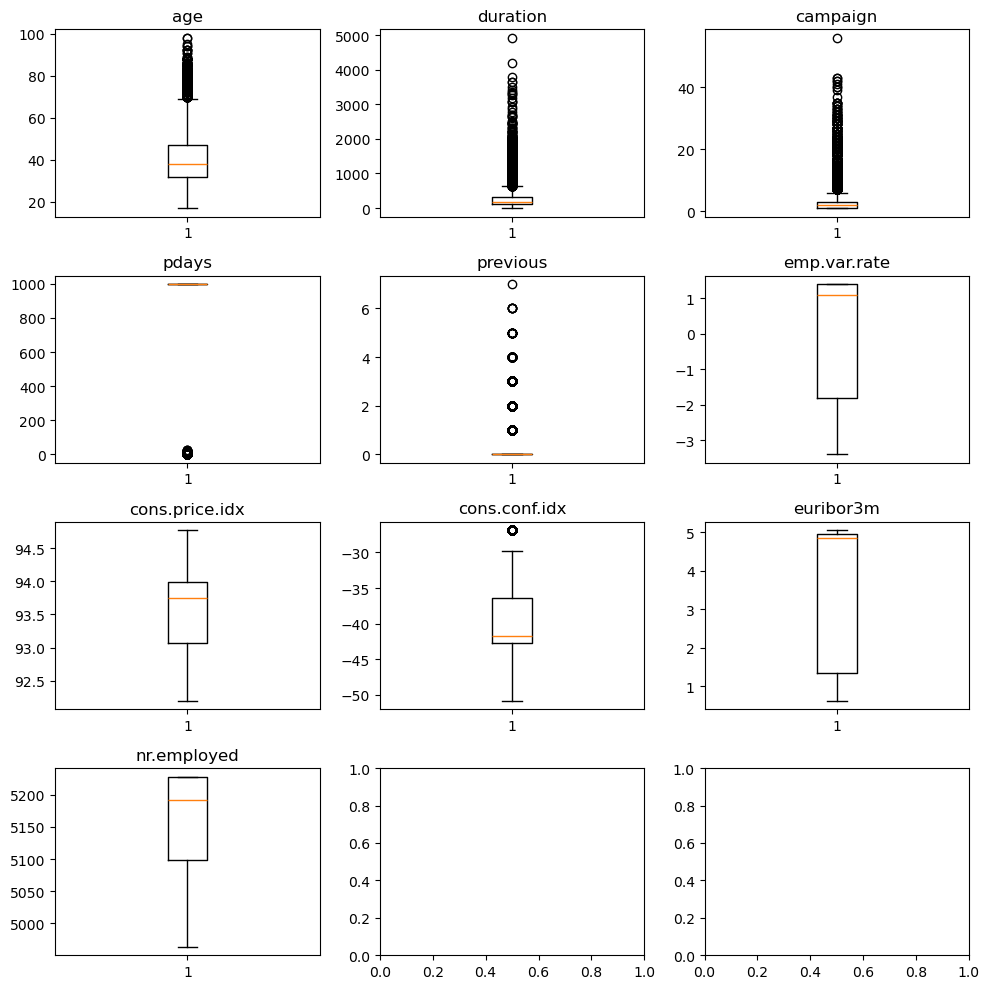

In [40]:
cols = df.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots(4, 3, figsize=(10, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [42]:
# Outlier detection using the IQR method (same 1.5*IQR rule as the boxplot whiskers)
cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col:20s} -> outliers: {len(outliers):6d}   (valid range: {lower:12.2f} to {upper:12.2f})")

age                  -> outliers:    469   (valid range:         9.50 to        69.50)
duration             -> outliers:   2963   (valid range:      -223.50 to       644.50)
campaign             -> outliers:   2406   (valid range:        -2.00 to         6.00)
pdays                -> outliers:   1515   (valid range:       999.00 to       999.00)
previous             -> outliers:   5626   (valid range:         0.00 to         0.00)
emp.var.rate         -> outliers:      0   (valid range:        -6.60 to         6.20)
cons.price.idx       -> outliers:      0   (valid range:        91.70 to        95.37)
cons.conf.idx        -> outliers:    446   (valid range:       -52.15 to       -26.95)
euribor3m            -> outliers:      0   (valid range:        -4.08 to        10.39)
nr.employed          -> outliers:      0   (valid range:      4905.60 to      5421.60)


In [43]:
outlier_columns = ["duration", "campaign", "cons.conf.idx"]

In [ ]:
print("Rows BEFORE removing outliers:", df.shape[0])

Rows BEFORE removing outliers: 41177


In [45]:
# Remove rows that fall outside the 1.5*IQR fence in any of the outlier columns
for col in outlier_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [ ]:
print("Rows AFTER removing outliers: ", df.shape[0])

Rows AFTER removing outliers:  35541


In [47]:
cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col:20s} -> outliers: {len(outliers):6d}   (valid range: {lower:12.2f} to {upper:12.2f})")

age                  -> outliers:    376   (valid range:         9.50 to        69.50)
duration             -> outliers:   1082   (valid range:      -169.00 to       551.00)
campaign             -> outliers:      0   (valid range:        -2.00 to         6.00)
pdays                -> outliers:   1287   (valid range:       999.00 to       999.00)
previous             -> outliers:   4982   (valid range:         0.00 to         0.00)
emp.var.rate         -> outliers:      0   (valid range:        -6.60 to         6.20)
cons.price.idx       -> outliers:      0   (valid range:        91.70 to        95.37)
cons.conf.idx        -> outliers:      0   (valid range:       -52.15 to       -26.95)
euribor3m            -> outliers:      0   (valid range:        -4.08 to        10.39)
nr.employed          -> outliers:      0   (valid range:      4905.60 to      5421.60)


<img src="./iqr_explainer.png" width="1440">